In [31]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
import pandas as pd
from scipy import signal
import seaborn as sns
from scipy.special import comb
sns.set()

# 10章演習問題

## (1)

遮断周波数１のアナログ低域フィルタの伝達関数$H_a(s)$とすると，
\begin{align*}
|H_a(s)| &= \left. \frac{1}{\sqrt{1+(-1)^N s^{2N}}} \right|_{s=j\omega}
\end{align*}

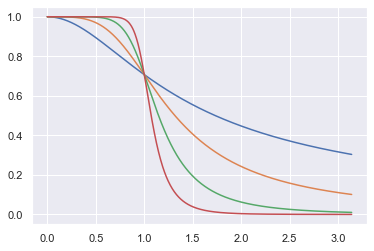

In [32]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)
for N in [1, 2, 4, 8]:
    H = 1.0 / np.sqrt(1.0 + omega**(2*N))
    plt.plot(omega, H)
plt.show()

i. $H_l(s)=H_a(s/\Omega_c)$

\begin{align*}
|H_a(s/\Omega_c)| &= \left. \frac{1}{\sqrt{1+(-1)^N (s/\Omega_c)^{2N}}} \right|_{s=j\omega}
\end{align*}

これは教科書の式(10.1)の低域フィルタと同じ．

ii. $H_h(s)=H_a(\Omega_c/s)$


\begin{align*}
|H_a(\Omega_c/a)| &= \left. \frac{1}{\sqrt{1+(-1)^N (\Omega_c/s)^{2N}}} \right|_{s=j\omega}\\
&= \frac{\omega^N}{\sqrt{\omega^{2N}+\Omega_c^{2N}}}\\
\end{align*}

上の式は$\omega=0$で0，$\omega \rightarrow \infty$で１，$\omega=\Omega_c$で$1/\sqrt{2}$であり，
遮断周波数$\Omega_c$の高域フィルタとなっている．

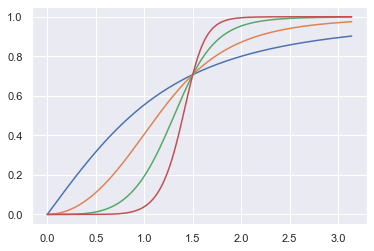

In [33]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)
omegac = 1.5
for N in [1, 2, 4, 8]:
    H = omega**N / np.sqrt(omega**(2*N) + omegac**(2*N))
    plt.plot(omega, H)
plt.show()

## (2)

### (a)

設計仕様
1. 通過域端周波数$\Omega_p$ [rad/sec]
2. 通過域リップル$R_p$ [dB]
3. 阻止域端周波数$\Omega_s$ [rad/sec]
4. 阻止域減衰量$A_s$ [dB]


また，１と2の仕様とバタワースフィルタの振幅特性が周波数$\Omega$に対して単調減少することから，

\begin{align*}
R_p &= \max_{\Omega \le \Omega_p} -20 \log_{10} |H_a(j\Omega)|\\
&= -20\log_{10}|H_a(j\Omega_p)|
\end{align*}

上式に教科書の式(10.1)を代入して

\begin{align*}
R_p &= 10 \log_{10} \left( 1 + \left( \frac{\Omega_p}{\Omega_c} \right)^{2N} \right)
\end{align*}

これを$\Omega_c$について解くと，

\begin{align*}
\Omega_c = \frac{\Omega_p}{(10^{Rp/10}-1)^{1/2N}}
\end{align*}

さらに，教科書式(10.11)の$\Omega_c$に代入して，

\begin{align*}
A_s &= 10\log_{10}\left(1 + \left( \frac{\Omega_s}{\Omega_p} \right)^{2N}(10^{Rp/10}-1) \right)
\end{align*}

これを$N$について解くと

\begin{align*}
N &= \frac{1}{2}\frac{\log_{10}\left( \frac{10^{A_s/10}-1}{10^{R_p/10}-1} \right)}{\log_{10}\left( \frac{\Omega_s}{\Omega_p}\right)}
\end{align*}
が得られる．

### (b)

In [34]:
Omegap = 0.2 * np.pi
Rp = 7.0
Omegas = 0.3 * np.pi
As = 16.0

r = 10**(Rp/10) - 1.0
a = 10**(As/10) - 1.0

N = np.ceil(0.5 * np.log10(a/r) / np.log10(Omegas/Omegap))

Omegac = Omegap / (r**(1/(2*N)))
print(f"N = {int(N):d}, Omegac = {Omegac/np.pi:.2f}pi")

N = 3, Omegac = 0.16pi


次数$N=3$，遮断周波数$\Omega_c \simeq 0.16\pi$なので，伝達関数は教科書表10.1のバタワース多項式を用いて，

\begin{align*}
H_a(s) &= \frac{1}{\left( (s/(0.16\pi)^2 + s/(0.16\pi) + 1 \right)\left( s/(0.16\pi) + 1 \right)}
\end{align*}

## (3) 安定なアナログフィルタ$H_a(s)$からインパルス不変変換法で設計されたディジタルフィルタ$H(z)$は必ず安定となることを示せ．

\begin{align*}
H(z) &= \Sigma_{k=1}^{N}\frac{A_k}{1-e^{-s_{k}}z^{-1}}\\
\end{align*}

をアナログフフィルタの極$p_k$を使って書くと，
\begin{align*}
H(z) &= \Sigma_{k=1}^{N}\frac{A_k}{1-e^{p_{k}}z^{-1}}\\
\end{align*}

ディジタルフィルタの極は$e^{p_k}$で，
\begin{align*}
e^{p_k} &= e^{{\rm Re}(p_k)}e^{j{\rm Im}(p_k)}\\
\end{align*}

安定なアナログフィルタの極は実部が負であるため，絶対値は１より小さい．よってこのディジタルフィルタは安定となる．

## (4)

### (a)

$s=j\Omega$と$z=e^{j\omega}$から
\begin{align*}
j\Omega &= 2\frac{1 - e^{-j\omega}}{1 + e^{-j\omega}}\\
&= 2\frac{e^{-j\omega/2}(e^{j\omega/2} - e^{-j\omega/2})}{e^{-j\omega/2}(e^{j\omega/2} + e^{-j\omega/2})}\\
&= 2j\tan (\omega/2)
\end{align*}
よって，$\Omega=2\tan (\omega/2)$

### (b)

\begin{align*}
s &= 2\frac{1 - z^{-1}}{1 + z^{-1}}\\
&= 2\frac{z - 1}{z + 1}\\
&= 2\frac{z - 1}{z + 1}\frac{z^* + 1}{z^* + 1}\\
&= 2\frac{|z|^2 + z - z^{*} -1}{|z + 1|^2}
\end{align*}

s平面上の虚軸は実部=0の集合なので，
\begin{align*}
{\rm Re}(s) = 2\frac{|z|^2 - 1}{|z + 1|^2} &= 0\\
|z|^2 - 1 &= 0\\
|z|^2 &= 1
\end{align*}
これは，z平面上の単位円を表している．

### (c)

(b)の結果からs平面上の左半平面は

\begin{align*}
{\rm Re}(s) = 2\frac{|z|^2 - 1}{|z + 1|^2} < 0
\end{align*}

式を整理して$|z|^2<1$が得られる．

### (d)

プロトタイプフィルタ$H_a(s)$が安定ならば極はs平面上の左半平面にある．このとき，(c)の結果から，双一次変換で得られる
$H(z)$の極の絶対値は1より小さいため$H(z)$は安定となる．

## (5)

### (a) $H_a(s) = \frac{s+1}{(s+a)^2+b^2}$

分母を展開して
\begin{align*}
H_a(s) &= \frac{s+a}{s^2 + 2as + a^2 + b^2}
\end{align*}

部分分数展開
\begin{align*}
\frac{q_0}{s-p_0} + \frac{q_1}{s-p_1}
&=\frac{(q_0 + q_1)s - (p_0q_1+p_1q_0)}{s^2 - (p_0 + p_1)s + p_0p_1}\\
\end{align*}
$q_0=q_1=1/2$と置いて，元の式と比較すると，

\begin{align*}
-p_0-p_1 &= 2a\\
p_0p_1 &= b^2
\end{align*}
これを解くことで$p_0=-a+jb$，$p_1=-a-jb$が得られる．したがって，

\begin{align*}
H_a(s) = \frac{1}{2}\left( \frac{1}{s-(-a+jb)} + \frac{1}{s-(-a-jb)} \right)
\end{align*}

インパルス不変変換により，

\begin{align*}
H(z) &= \frac{1}{2}\left( \frac{1}{1 - e^{-a+jb}z^{-1}} + \frac{1}{1 - e^{-a-jb}z^{-1}} \right)\\
&= \frac{1}{2}\left( \frac{1}{1 - e^{-a}e^{jb}z^{-1}} + \frac{1}{1 - e^{-a}e^{-jb}z^{-1}} \right)\\
\end{align*}

### (b) $H_a(s) = \frac{b}{(s+a)^2+b^2}$

(a)と同様に，

\begin{align*}
H_a(s) &= \frac{b}{s^2 + 2as + a^2 + b^2}
\end{align*}
と
\begin{align*}
\frac{q_0}{s-p_0} + \frac{q_1}{s-p_1}
&=\frac{(q_0 + q_1)s - (p_0q_1+p_1q_0)}{s^2 - (p_0 + p_1)s + p_0p_1}\\
\end{align*}
を比較して部分分数展開する．

\begin{align*}
H_a(s) = j2b^2\left( \frac{1}{s-(-a+jb)} - \frac{1}{s-(-a-jb)} \right)
\end{align*}

インパルス不変変換により，

\begin{align*}
H(z) &= j2b^2\left( \frac{1}{1 - e^{-a}e^{jb}z^{-1}} - \frac{1}{1 - e^{-a}e^{-jb}z^{-1}} \right)\\
\end{align*}

## (6)

### (a)

教科書のバタワース多項式の表から

\begin{align*}
H_a(s) &= \frac{1}{1+s/\omega_c}\\
|H_a(s)| &= \frac{1}{\sqrt{1+(\omega/\omega_c)^2}}
\end{align*}

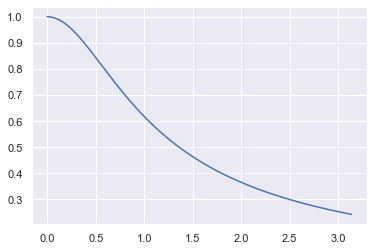

In [35]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)

omegac = 0.25 * np.pi
H = 1.0 / np.sqrt(1.0 + (omega/omegac)**2)
plt.plot(omega, H)
plt.show()

### (b)

(a)の式から

\begin{align*}
H_i(z) &= \frac{\omega_c}{1-e^{-\omega_c}z^{-1}}\\
|H_i(e^{j\omega})| &= \frac{\omega_c}{\sqrt{1-2e^{-\omega_c}\cos \omega + e^{-2\omega_c}}}
\end{align*}

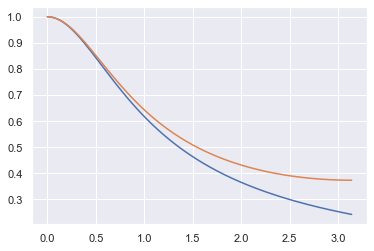

In [36]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)

omegac = 0.25 * np.pi
Hi = omegac / np.sqrt(1.0 - 2.0 * np.exp(-omegac) * np.cos(omega) + np.exp(-2*omegac))
plt.plot(omega, H)
plt.plot(omega, Hi/Hi.max())
plt.show()

インパルス不変変換で求めた伝達関数の振幅特性の最大値が１より大きくなってしまうので最大値で割った．

### (c), (d)

\begin{align*}
H_b(z) &= \frac{\omega_c}{2\frac{1-z^{-1}}{1+z^{-1}}+\omega_c}\\
&= \frac{\omega_c(1+z^{-1})}{\omega_c+2+(\omega_c-2)z^{-1}}\\
|H_i(e^{j\omega})| &= \frac{\omega_c\sqrt{1+\cos \omega}}{\sqrt{ (\omega_c^2+4) +(\omega_c^2-4)\cos \omega}}
\end{align*}

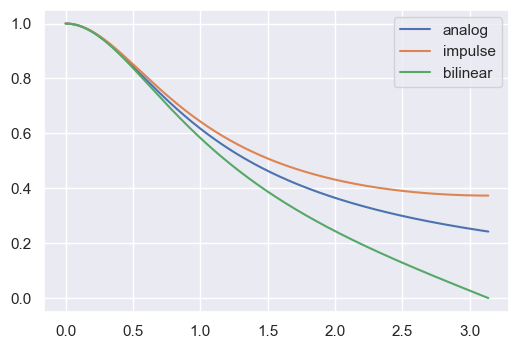

In [37]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)

omegac = 0.25 * np.pi
Hb = omegac * np.sqrt(1+np.cos(omega)) / np.sqrt((omegac**2+4) + (omegac**2-4) * np.cos(omega))
plt.figure(dpi=100)
plt.plot(omega, H, label="analog")
plt.plot(omega, Hi/Hi.max(), label="impulse")
plt.plot(omega, Hb, label="bilinear")
plt.legend()
plt.show()

## (7) $H_a(s) = \frac{s}{s^2 + 2\zeta \Omega_n s + \Omega_n^2}$

### (a) 極と零点
零点$z=0$，極は$p_k$として，
\begin{align*}
　p_k &= \frac{1}{2}\left( -2\zeta \Omega_n \pm \sqrt{4\zeta^2 \Omega_n^2 - 4\Omega_n^2} \right)\\
&= -\zeta\Omega_n \pm j\left( \Omega_n \sqrt{1-\zeta^2} \right)
\end{align*}

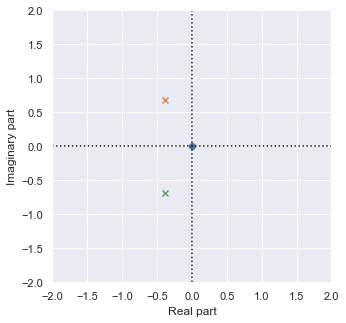

In [38]:
zeta = 0.5
Omegan = np.pi / 4.0

z = complex(0.0, 0.0)
p1 = complex(-zeta*Omegan, Omegan * np.sqrt(1.0 - zeta**2))
p2 = complex(-zeta*Omegan, -Omegan * np.sqrt(1.0 - zeta**2))

plt.figure(figsize=(5, 5))
plt.scatter(z.real, z.imag, marker="o")
plt.scatter(p1.real, p1.imag, marker="x")
plt.scatter(p2.real, p2.imag, marker="x")

plt.hlines(y=0, xmin=-2, xmax=2, linestyle="dotted")
plt.vlines(x=0, ymin=-2, ymax=2, linestyle="dotted")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.show()

### (b) 振幅特性

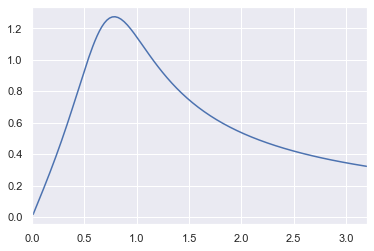

In [39]:
zeta = 0.5
Omegan = np.pi / 4.0

wa, Ha = signal.freqs(b=[1.0, 0.0], a=[1.0, 2*zeta*Omegan, Omegan**2])

plt.plot(wa, np.abs(Ha))
plt.xlim(0, 3.2)
plt.show()

### (c) インパルス不変変換

求めた極を改めて
\begin{align*}
p_1 &= -\zeta\Omega_n + j\left( \Omega_n \sqrt{1-\zeta^2} \right)\\
p_2 &= -\zeta\Omega_n - j\left( \Omega_n \sqrt{1-\zeta^2} \right)\\
\end{align*}

として

\begin{align*}
\frac{A_1}{s-p_1} + \frac{A_2}{s-p_2} &= \frac{A_1(s-p_2) + A_2(s-p_1)}{s^2 - (p_1 + p_2)s + p_1p_2}\\
&= \frac{s}{s^2 + \zeta \Omega_n s + \Omega_n^2}
\end{align*}

分子比較して，$A_1+A_2=1$，$A_1p_2+A_2p_1=0$
\begin{align*}
A_1(p_2 - p_1) + p_1 &= 0\\
A_1 &= \frac{1}{2}\left( 1 + j \frac{\zeta}{\sqrt{1-\zeta^2}} \right)\\
A_2 &= \frac{1}{2}\left( 1 - j \frac{\zeta}{\sqrt{1-\zeta^2}} \right) = A_1^*\\
\end{align*}

インパルス不変変換により，
\begin{align*}
H(z) &= \frac{A_1}{1-e^{p_1}z^{-1}} + \frac{A_2}{1-e^{p_2}z^{-1}}\\
&= \frac{A_1+A_2 - (A_1e^{p_2} + A_2e^{p_1})z^{-1}}{1 - (e^{p_1} + e^{p_2})z^{-1} + e^{p_1}e^{p_2}z^{-2}}
\end{align*}

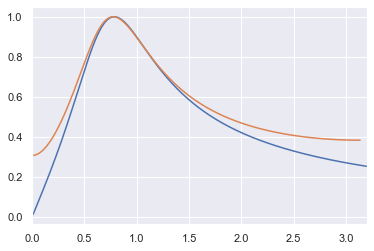

In [40]:
A1 = 0.5 * complex(1.0, zeta / np.sqrt(1.0 - zeta**2))
A2 = np.conj(A1)

p1 = complex(-zeta*Omegan, Omegan * np.sqrt(1.0 - zeta**2))
p2 = np.conj(p1)

ep1 = np.exp(p1)
ep2 = np.exp(p2)

wi, Hi = signal.freqz(b=[A1+A2, -(A1*ep2 + A2*ep1)], a=[1.0, -(ep1 + ep2), ep1*ep2])

plt.plot(wa, np.abs(Ha)/np.abs(Ha).max())
plt.plot(wi, np.abs(Hi)/np.abs(Hi).max())
plt.xlim(0, 3.2)
plt.show()

### (d) 双一次変換

\begin{align*}
H(z) &= \frac{2\frac{1-z^{-1}}{1+z^{-1}}}{\left( 2\frac{1-z^{-1}}{1+z^{-1}} \right)^2
+ 2\zeta\Omega_n 2\frac{1-z^{-1}}{1+z^{-1}} + \Omega_n^2}\\
&= \frac{2(1-z^{-2})}{\Omega_n^2+4\zeta\Omega_n+4 + 2(\Omega_n^2-4)z^{-1} + (\Omega_n^2-4\zeta\Omega_n+4)z^{-2}}
\end{align*}

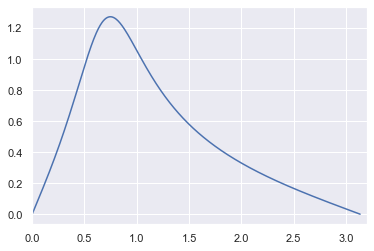

In [41]:
zeta = 0.5
Omegan = np.pi / 4.0

a0 = Omegan**2 + 4.0 * zeta * Omegan + 4.0
a1 = 2.0 * (Omegan**2 - 4.0)
a2 = Omegan**2 - 4.0 * zeta * Omegan + 4.0

wb, Hb = signal.freqz(b=[2.0, 0.0, -2.0], a=[a0, a1, a2])

plt.plot(wb, np.abs(Hb))
plt.xlim(0, 3.2)
plt.show()

### (e)

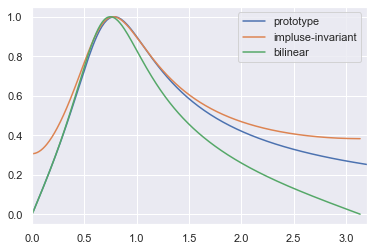

In [42]:
plt.plot(wa, np.abs(Ha)/np.abs(Ha).max(), label="prototype")
plt.plot(wi, np.abs(Hi)/np.abs(Hi).max(), label="impluse-invariant")
plt.plot(wb, np.abs(Hb)/np.abs(Hb).max(), label="bilinear")
plt.legend()
plt.xlim(0, 3.2)
plt.show()

## (8)

設計仕様

In [76]:
omegac = 0.25 * np.pi # [rad]
omegas = 0.5 * np.pi # [rad]
As = 20.0 # [dB]

print(omegac, omegas)

0.7853981633974483 1.5707963267948966


式(10.12)から，バターワースフィルタの次数$N$を求める．

In [72]:
N = np.ceil(0.5 * np.log10(10**(As/10)-1.0)/np.log10(omegas/omegac))
N

4.0

式(10.5)から極を計算する．

In [45]:
pk = [omegac * np.exp(np.complex(0,(2*k+1)*np.pi/(2.0*N))) for k in range(2*int(N))]
pk

[(0.7256132880348577+0.30055886494217315j),
 (0.30055886494217315+0.7256132880348577j),
 (-0.3005588649421731+0.7256132880348577j),
 (-0.7256132880348577+0.30055886494217315j),
 (-0.7256132880348577-0.30055886494217304j),
 (-0.30055886494217354-0.7256132880348576j),
 (0.3005588649421733-0.7256132880348576j),
 (0.7256132880348576-0.3005588649421736j)]

上で求めた極の中で，s平面の左半平面にある4個の極を選ぶ．

In [46]:
pk_stable = [pk[2], pk[5], pk[3], pk[4]]
pk_stable

[(-0.3005588649421731+0.7256132880348577j),
 (-0.30055886494217354-0.7256132880348576j),
 (-0.7256132880348577+0.30055886494217315j),
 (-0.7256132880348577-0.30055886494217304j)]

アナログフィルタの振幅特性

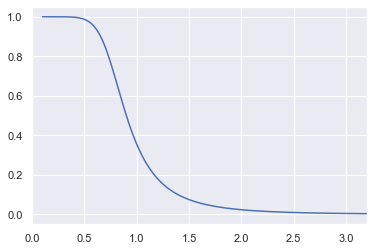

In [87]:
# ２次の係数一つ目．複素共役の二つの極で計算．
a00 = 1.0
a01 = -2.0*pk_stable[0].real
a02 = np.abs(pk_stable[0])**2

# 2次の係数二つ目
a10 = 1.0
a11 = -2.0*pk_stable[2].real
a12 = np.abs(pk_stable[2])**2

# 4次の係数
a0 = 1.0
a1 = a01 + a11
a2 = a02 + a12 + (a01 * a11)
a3 = (a01 * a12) + (a02 * a11)
a4 = a02 * a12

# 伝達関数
wa, Ha = signal.freqs(b=[omegac**4], a=[a0, a1, a2, a3, a4])
plt.plot(wa, np.abs(Ha))
plt.xlim(0, 3.2)
plt.show()

バタワース多項式の表を使う場合

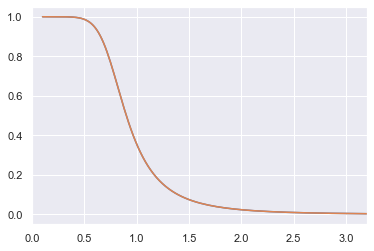

In [89]:
wa, Ha1 = signal.freqs(b=[omegac**2], a=[1.0, 0.7653*omegac, omegac**2])
_, Ha2 = signal.freqs(b=[omegac**2], a=[1.0, 1.848*omegac, omegac**2])

plt.plot(wa, np.abs(Ha))
plt.plot(wa, np.abs(Ha1*Ha2))
plt.xlim(0, 3.2)
plt.show()

部分分数展開

In [90]:
Ak, sk, k = signal.residue(b=[omegac**4], a=[a0, a1, a2, a3, a4])
print(Ak)
print(sk)
print(k)

[-0.36280664+0.15027943j -0.36280664-0.15027943j  0.36280664-0.87589272j
  0.36280664+0.87589272j]
[-0.30055886+0.72561329j -0.30055886-0.72561329j -0.72561329+0.30055886j
 -0.72561329-0.30055886j]
[]


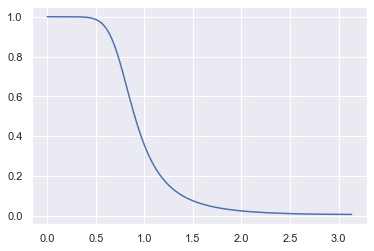

In [91]:
wi, Hi0 = signal.freqz(b=[Ak[0]], a=[1.0, -np.exp(sk[0])])
_, Hi1 = signal.freqz(b=[Ak[1]], a=[1.0, -np.exp(sk[1])])
_, Hi2 = signal.freqz(b=[Ak[2]], a=[1.0, -np.exp(sk[2])])
_, Hi3 = signal.freqz(b=[Ak[3]], a=[1.0, -np.exp(sk[3])])
Hi = Hi0 + Hi1 + Hi2 + Hi3
plt.plot(wi, np.abs(Hi))

(0.0, 3.2)

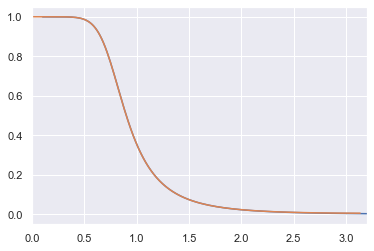

In [92]:
plt.plot(wa, np.abs(Ha))
plt.plot(wi, np.abs(Hi))
plt.xlim(0,3.2)

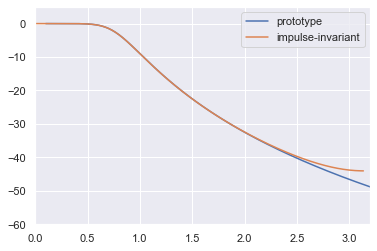

In [100]:
plt.plot(wa, 20*np.log10(np.abs(Ha)), label="prototype")
plt.plot(wi, 20*np.log10(np.abs(Hi)), label="impulse-invariant")
plt.ylim(-60, 5)
plt.xlim(0,3.2)
plt.legend()
plt.show()

## (9)

プリワーピング

In [65]:
Omega_c = 2.0 * np.tan(np.pi / 8.0)
Omega_s = 2.0 * np.tan(np.pi / 4.0)
As = 20.0

プロトタイプフィルタ

In [54]:
N = np.ceil(0.5 * np.log10(10**(As/10.0) - 1.0) / np.log10(Omega_s / Omega_c))
print(N)

3.0


3次バタワースフィルタは教科書の表10.1から

\begin{align*}
H_a(s) &= \frac{1}{\left((s/\Omega_c)^2 + (s/\Omega_c) + 1 \right)\left( (s/\Omega_c) + 1 \right)}\\
&= \frac{\Omega_c^3}{s^3 + 2\Omega_c s^2 + 2\Omega_c^2 s + \Omega_c^3}
\end{align*}

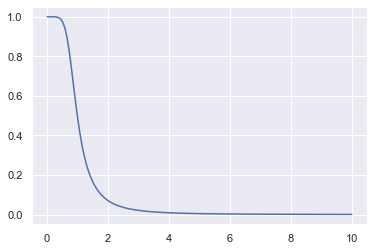

In [66]:
wa, Ha = signal.freqs(b=[Omega_c**3], a=[1.0, 2.0*Omega_c, 2.0*Omega_c**2, Omega_c**3])
plt.plot(wa, np.abs(Ha))

双一次変換

\begin{align*}
H(z) &= \frac{\Omega_c^3}{\left(2\frac{1-z^{-1}}{1+z^{-1}}\right)^3 + 2\Omega_c \left(2\frac{1-z^{-1}}{1+z^{-1}}\right)^2
+ 2\Omega_c^2 \left(2\frac{1-z^{-1}}{1+z^{-1}}\right) + \Omega_c^3}\\
&= \frac{\Omega_c^3 (1 + 3z^{-1} + 3z^{-2} + z^{-3})}{\Omega_c^3+4\Omega_c^2+8\Omega_c+8 + (3\Omega_c^3+4\Omega_c^2-8\Omega_c-24)z^{-1}
(3\Omega_c^3-4\Omega_c^2-8\Omega_c+24)z^{-2} + (\Omega_c^3-4\Omega_c^2+8\Omega_c-8)z^{-3}}
\end{align*}

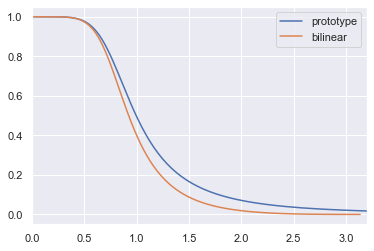

In [68]:
a0 = Omega_c**3 + 4.0 * Omega_c**2 + 8.0 * Omega_c + 8.0
a1 = 3.0 * Omega_c**3 + 4.0 * Omega_c**2 - 8.0 * Omega_c -24.0
a2 = 3.0 * Omega_c**3 - 4.0 * Omega_c**2 - 8.0 * Omega_c + 24.0
a3 = Omega_c**3 - 4.0 * Omega_c**2 + 8.0 * Omega_c - 8.0

ab = np.array([a0, a1, a2, a3])
bb = np.array([1.0, 3.0, 3.0, 1.0]) * (Omega_c**3)
wz, Hb = signal.freqz(b=bb, a=ab)

plt.plot(wa, np.abs(Ha), label="prototype")
plt.plot(wz, np.abs(Hb), label="bilinear")
plt.xlim(0, 3.2)
plt.legend()
plt.show()